<a href="https://colab.research.google.com/github/HimanshiChoubal/Major_Project/blob/master/QCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 59.4 MB/s eta 0:00:00


In [ ]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import pennylane as qml, matplotlib.pyplot as plt, time, warnings
from matplotlib.patches import FancyBboxPatch
from torchvision.datasets import EuroSAT
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore"); torch.set_default_dtype(torch.float64)

CLASS_A, CLASS_B = "Highway", "River"   # any two EuroSAT classes
N_PER_CLASS = 500
N_QUBITS = 8                            # = number of PCA features
TRAIN_SIZES = [8, 16, 32, 64]           # labelled images
SEEDS = 3
EPOCHS = 100

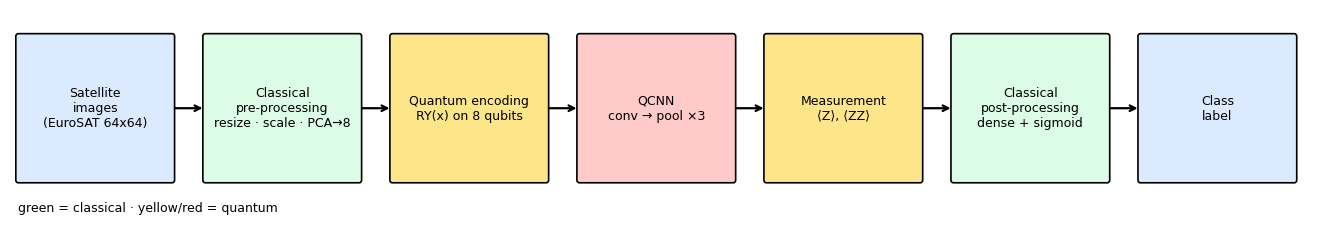

In [ ]:
steps = [("Satellite\nimages\n(EuroSAT 64x64)", "#dbeafe"), ("Classical\npre-processing\nresize · scale · PCA→8", "#dcfce7"),
         ("Quantum encoding\nRY(x) on 8 qubits", "#fde68a"), ("QCNN\nconv → pool ×3", "#fecaca"),
         ("Measurement\n⟨Z⟩, ⟨ZZ⟩", "#fde68a"), ("Classical\npost-processing\ndense + sigmoid", "#dcfce7"), ("Class\nlabel", "#dbeafe")]
fig, ax = plt.subplots(figsize=(17, 2.8)); ax.axis("off"); w, g = 1.85, 0.4
for i, (t, c) in enumerate(steps):
    x = i * (w + g)
    ax.add_patch(FancyBboxPatch((x, 0), w, 1.6, boxstyle="round,pad=0.03", fc=c, ec="k", lw=1.2))
    ax.text(x + w / 2, 0.8, t, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1: ax.annotate("", xy=(x + w + g, 0.8), xytext=(x + w, 0.8), arrowprops=dict(arrowstyle="->", lw=1.6))
ax.text(0, -0.35, "green = classical · yellow/red = quantum", fontsize=9)
ax.set_xlim(-0.1, len(steps) * (w + g)); ax.set_ylim(-0.5, 1.9); plt.show()

100%|██████████| 94.3M/94.3M [00:00<00:00, 96.8MB/s]


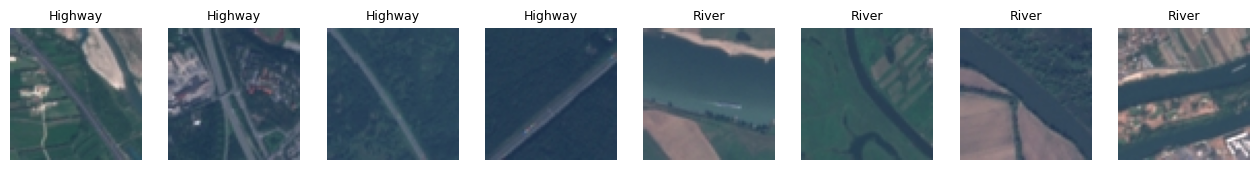

pool (600, 8) test (400, 8) | PCA variance kept: 0.72


In [ ]:
ds = EuroSAT(root="data", download=True)
rng = np.random.default_rng(0); tg = np.array(ds.targets)
ia, ib = ds.class_to_idx[CLASS_A], ds.class_to_idx[CLASS_B]
ids = np.concatenate([rng.choice(np.where(tg == c)[0], N_PER_CLASS, replace=False) for c in (ia, ib)])
imgs = [ds[i][0] for i in ids]; y = (tg[ids] == ib).astype(int)

fig, ax = plt.subplots(1, 8, figsize=(16, 2.4))
for k, a in enumerate(ax):
    a.imshow(imgs[k if k < 4 else N_PER_CLASS + k - 4]); a.axis("off"); a.set_title(CLASS_A if k < 4 else CLASS_B, fontsize=9)
plt.show()

X = np.stack([np.asarray(im.resize((16, 16))) / 255.0 for im in imgs]).reshape(len(imgs), -1)   # resize + normalise
Xp_raw, Xt_raw, yp, yt = train_test_split(X, y, test_size=0.4, stratify=y, random_state=0)
sc = StandardScaler().fit(Xp_raw); pca = PCA(N_QUBITS, random_state=0).fit(sc.transform(Xp_raw))
Z = lambda A: pca.transform(sc.transform(A)); mm = MinMaxScaler((0, np.pi)).fit(Z(Xp_raw))
Xp = np.clip(mm.transform(Z(Xp_raw)), 0, np.pi); Xt = np.clip(mm.transform(Z(Xt_raw)), 0, np.pi)
print("pool", Xp.shape, "test", Xt.shape, "| PCA variance kept: %.2f" % pca.explained_variance_ratio_.sum())

In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)

def conv_block(w, i, j):                       # 9 shared params
    qml.Rot(w[0], w[1], w[2], wires=i); qml.Rot(w[3], w[4], w[5], wires=j)
    qml.CNOT(wires=[i, j]); qml.RY(w[6], wires=i); qml.RZ(w[7], wires=j)
    qml.CNOT(wires=[j, i]); qml.RY(w[8], wires=i)

def pool_block(w, src, sink):                  # 2 shared params, src is discarded afterwards
    qml.CRZ(w[0], wires=[src, sink]); qml.PauliX(wires=src); qml.CRX(w[1], wires=[src, sink])

def conv_layer(w, act):
    n = len(act)
    for k in range(0, n - 1, 2): conv_block(w, act[k], act[k + 1])
    if n > 2:
        for k in range(1, n, 2): conv_block(w, act[k], act[(k + 1) % n])

def pool_layer(w, act):
    for k in range(0, len(act), 2): pool_block(w, act[k], act[k + 1])
    return act[1::2]

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qcnn(x, cw, pw):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")     # quantum encoding
    act = list(range(N_QUBITS))
    for l in range(2):                                             # 8→4→2
        conv_layer(cw[l], act); act = pool_layer(pw[l], act)
    conv_layer(cw[2], act)                                         # final conv on 2 qubits
    a, b = act
    return [qml.expval(qml.PauliZ(a)), qml.expval(qml.PauliZ(b)), qml.expval(qml.PauliZ(a) @ qml.PauliZ(b))]

print(qml.draw(qcnn)(torch.zeros(N_QUBITS), torch.zeros(3, 9), torch.zeros(2, 2)))

class HybridQCNN(nn.Module):                   # classical pre-proc (outside) → QCNN → classical post-proc
    def __init__(self):
        super().__init__()
        self.cw = nn.Parameter(0.3 * torch.randn(3, 9)); self.pw = nn.Parameter(0.3 * torch.randn(2, 2))
        self.head = nn.Linear(3, 1)            # classical post-processing
    def forward(self, x):
        q = torch.stack(list(qcnn(x, self.cw, self.pw)), dim=-1)
        return self.head(q).squeeze(-1)

class ClassicalCNN(nn.Module):                 # classical counterpart over the same 8 features
    def __init__(self, c1, c2):
        super().__init__()
        self.c1 = nn.Conv1d(1, c1, 3, padding=1); self.c2 = nn.Conv1d(c1, c2, 3, padding=1)
        self.head = nn.Linear(c2 * 2, 1)       # same post-processing role
    def forward(self, x):
        h = F.max_pool1d(torch.tanh(self.c1(x.unsqueeze(1))), 2)
        h = F.max_pool1d(torch.tanh(self.c2(h)), 2)
        return self.head(h.flatten(1)).squeeze(-1)

count = lambda m: sum(p.numel() for p in m.parameters())
MODELS = {"Classical CNN (matched)": lambda: ClassicalCNN(2, 3),
          "Classical CNN (large)": lambda: ClassicalCNN(16, 32),
          "QCNN (hybrid)": lambda: HybridQCNN()}
params = {k: count(f()) for k, f in MODELS.items()}; print(params)

0: ─╭AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╭●──RY(0.00)─╭X──RY(0.00)─────────── ···
1: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╰X──RZ(0.00)─╰●──Rot(0.00,0.00,0.00) ···
2: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╭●──RY(0.00)─╭X──RY(0.00)─────────── ···
3: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╰X──RZ(0.00)─╰●──Rot(0.00,0.00,0.00) ···
4: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╭●──RY(0.00)─╭X──RY(0.00)─────────── ···
5: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╰X──RZ(0.00)─╰●──Rot(0.00,0.00,0.00) ···
6: ─├AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╭●──RY(0.00)─╭X──RY(0.00)─────────── ···
7: ─╰AngleEmbedding(M0)──Rot(0.00,0.00,0.00)─╰X──RZ(0.00)─╰●──Rot(0.00,0.00,0.00) ···

0: ··· ──Rot(0.00,0.00,0.00)───────────────────────────╭X──RZ(0.00)─╭●─╭●─────────X─────── ···
1: ··· ──────────────────────╭●──RY(0.00)─╭X──RY(0.00)─│────────────│──╰RZ(0.00)────────── ···
2: ··· ──Rot(0.00,0.00,0.00)─╰X──RZ(0.00)─╰●───────────│────────────│──╭●─────────X─────── ···
3: ··· ───────────────────

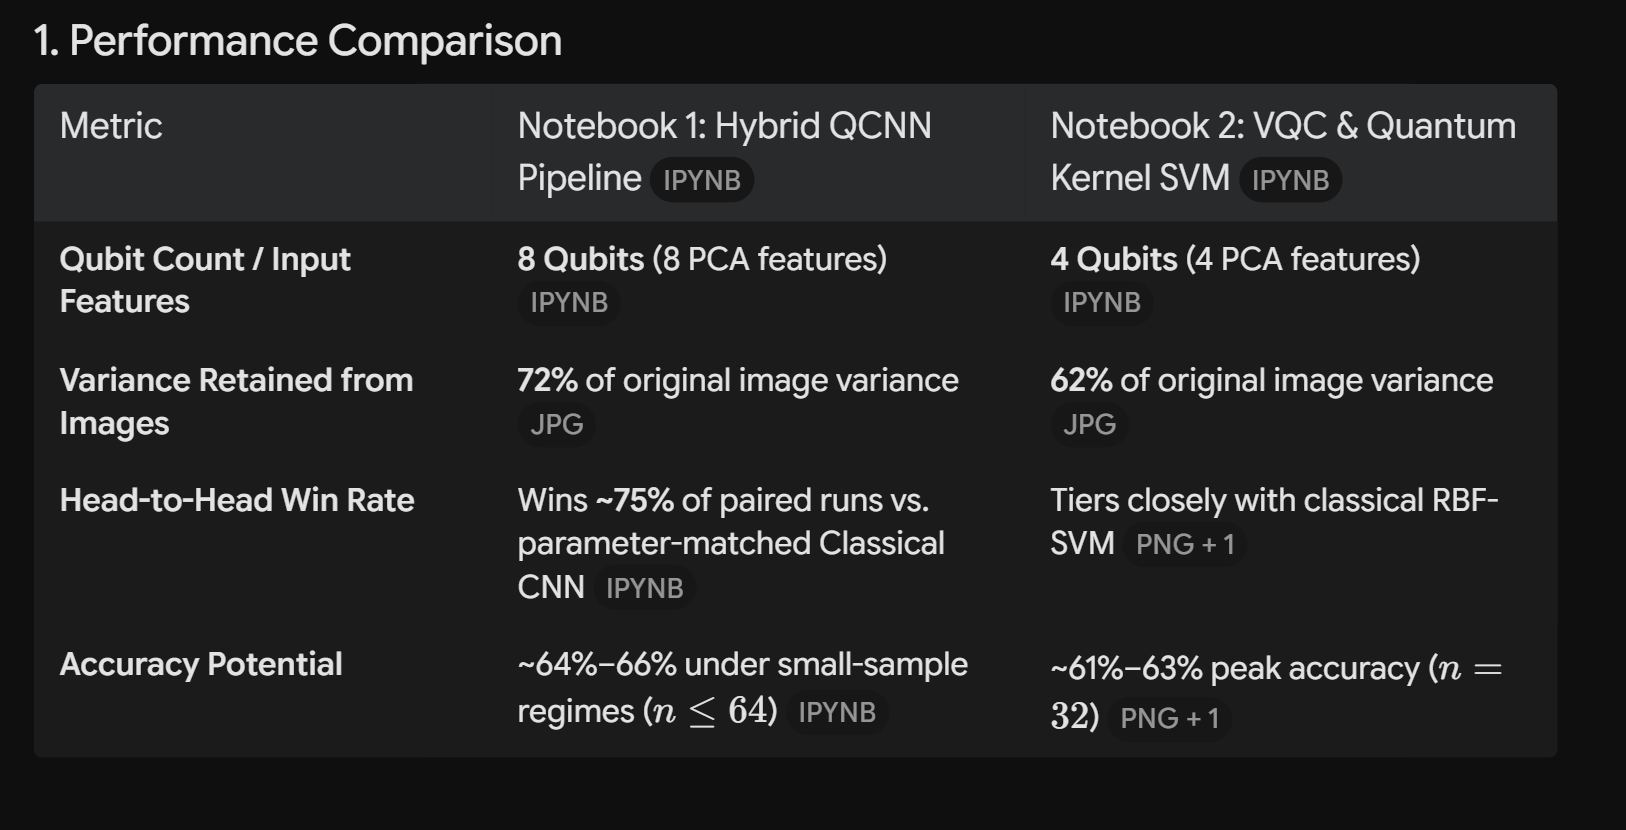